In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from skimage import measure, morphology
import rasterio
import seaborn as sns
from src.classification import run_classification_workflow
from src.basic_statistics import run_statistics_workflow
from src.segmentation import run_segmentation_workflow

In [10]:
path = "/Users/devseed/Documents/repos/OBIA_workflow/data/ortho_subset_I.tif"

Loading Sentinel-2 image...
Image loaded: (1500, 1500)
Calculating spectral indices...
Performing K-means segmentation with 6 clusters...


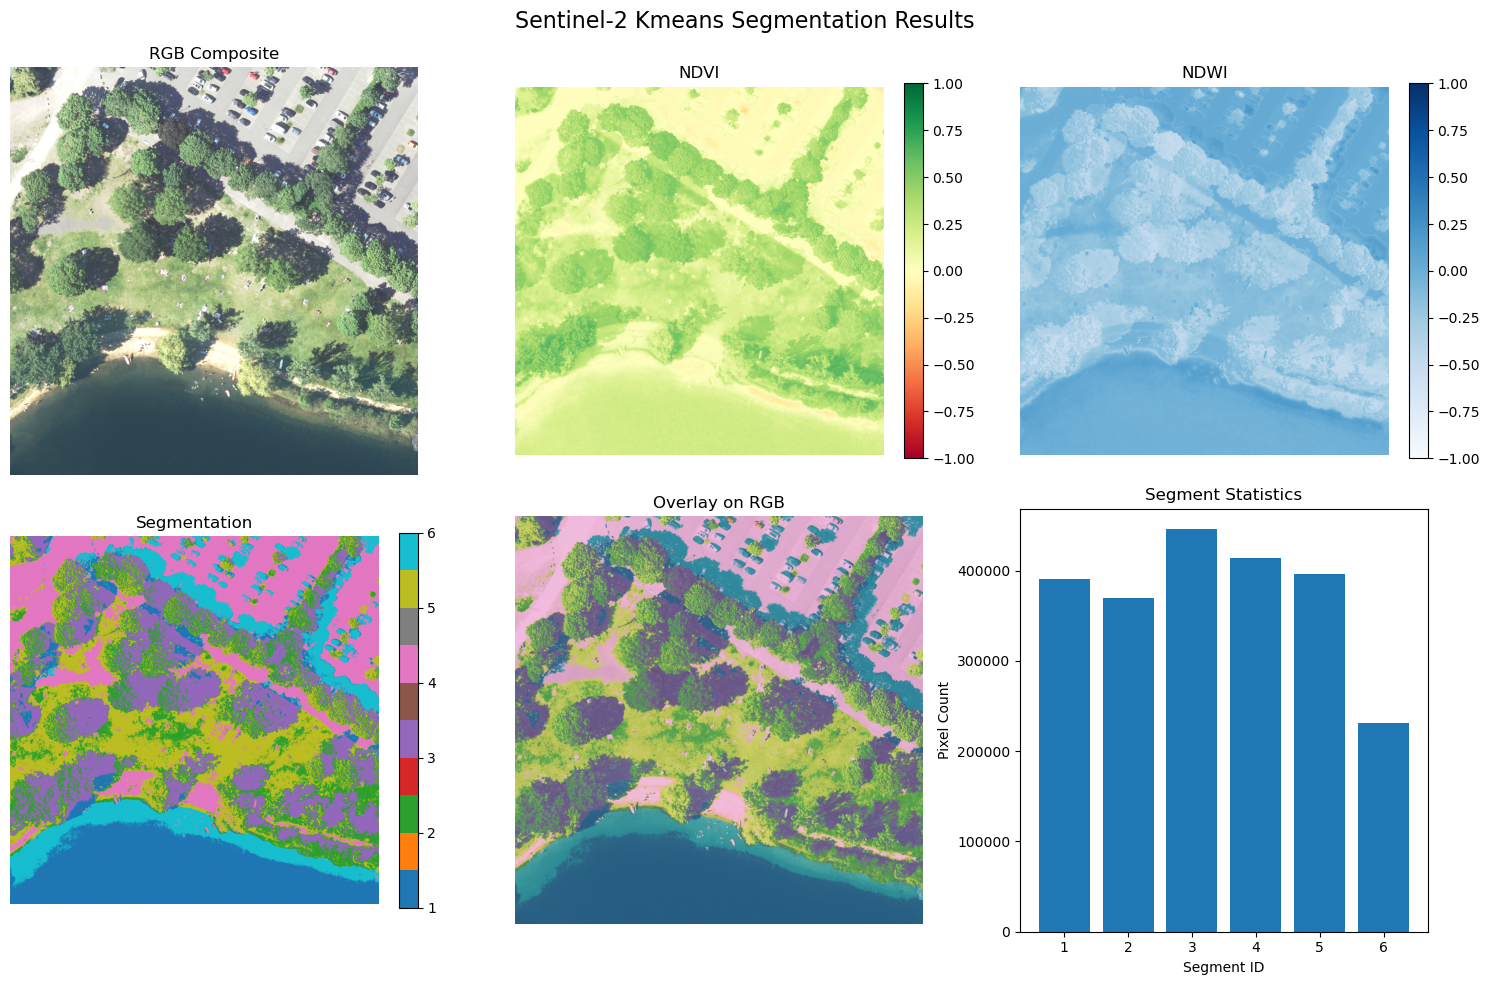


Segmentation Statistics:
segment_1: 391313 pixels, NDVI: 0.207, NDWI: -0.044
segment_2: 370316 pixels, NDVI: 0.335, NDWI: -0.254
segment_3: 446569 pixels, NDVI: 0.442, NDWI: -0.379
segment_4: 414084 pixels, NDVI: 0.003, NDWI: -0.004
segment_5: 396500 pixels, NDVI: 0.197, NDWI: -0.152
segment_6: 231218 pixels, NDVI: 0.025, NDWI: 0.030


In [11]:
segments = run_segmentation_workflow(path, method='kmeans')[2]

Loading image for statistics...
Extracting objects...
Found 6 objects
Calculating spectral statistics...
Calculating geometric statistics...
Calculating texture statistics...
Merging all statistics...
Statistics calculated for 6 objects


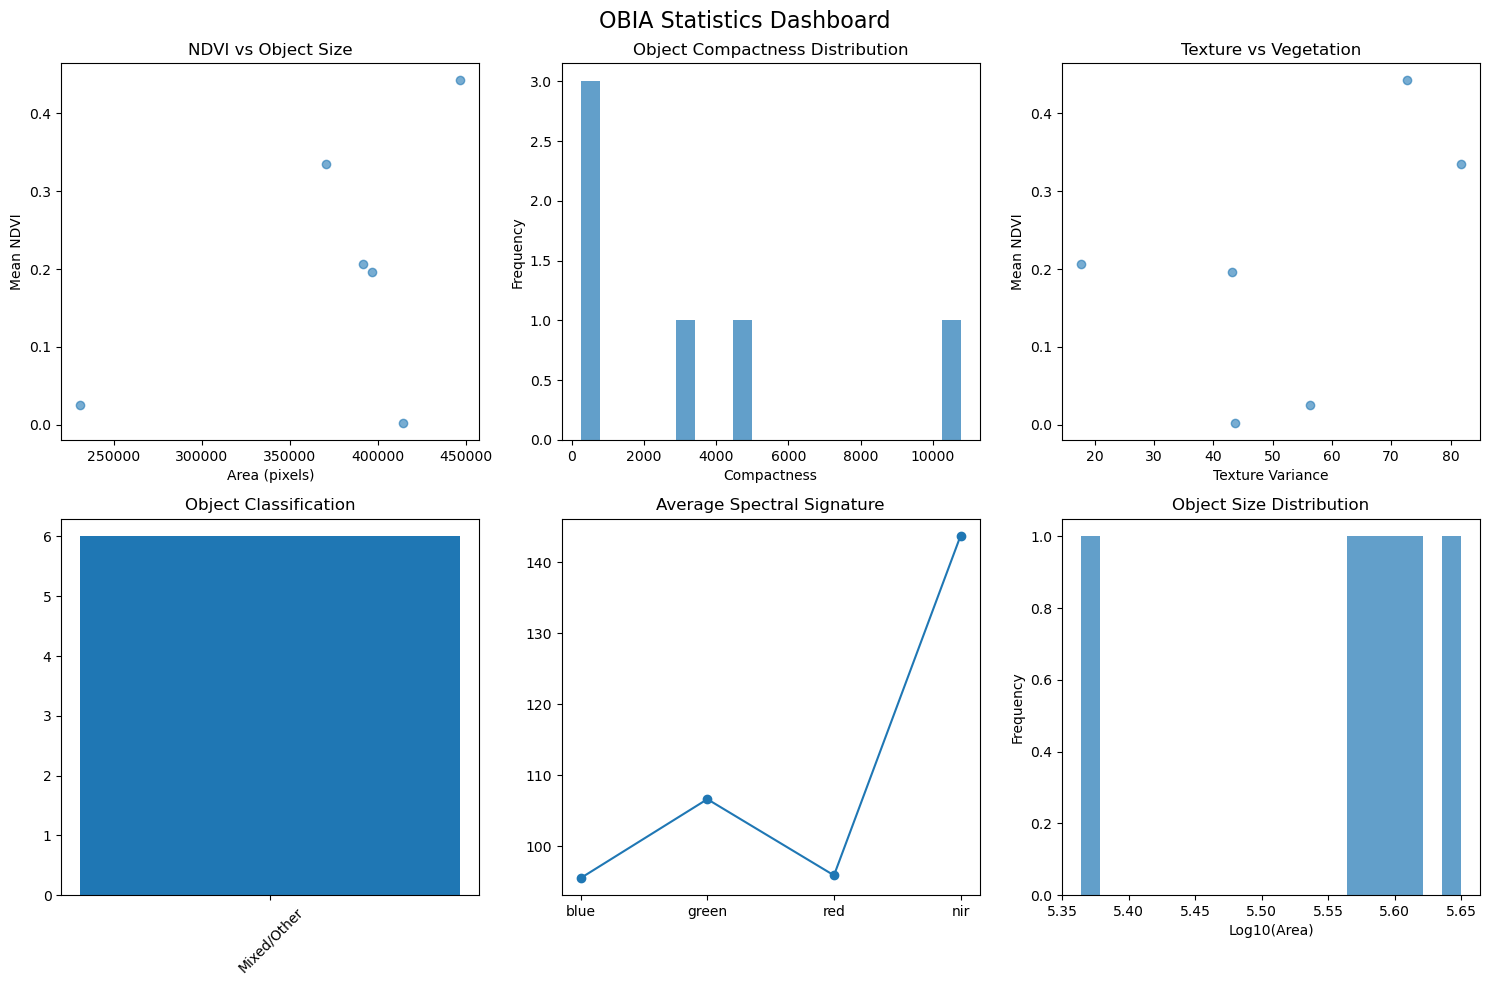


=== OBIA STATISTICS SUMMARY ===
Total objects analyzed: 6
Total area covered: 2250000.0 pixels
Average object size: 375000.0 pixels
Size range: 231218.0 - 446569.0 pixels

Spectral Statistics:
Mean NDVI: 0.201 ± 0.171
Mean NDWI: -0.134 ± 0.159

Classification Results:
  Mixed/Other: 6 objects (100.0%)


In [12]:
stats_df = run_statistics_workflow(path, segments=segments)[0]

In [13]:
run_classification_workflow(path, segments=segments, stats_df=stats_df)

Preparing features...
Creating training labels...
Training samples per class:
labels
Mixed    3
Name: count, dtype: int64


(   object_id   blue_mean   blue_std  blue_median  green_mean  green_std  \
 0          1   64.091667   5.703335         63.0   56.166058   6.181382   
 1          2   88.177116   9.260064         88.0  117.395012  14.975396   
 2          3   64.775482   7.649946         64.0   68.064400  11.794559   
 3          4  162.991013  15.737936        161.0  170.843323  15.626403   
 4          5  111.662186  12.302408        110.0  150.939301  11.308174   
 5          6   81.296890  12.662443         79.0   76.281471  14.758487   
 
    green_median    red_mean    red_std  red_median  ...   compactness  \
 0          55.0   40.890980   9.364421        38.0  ...    241.668687   
 1         118.0   98.142601  11.972006        99.0  ...  10772.637581   
 2          66.0   58.079254   9.743483        56.0  ...   3258.867808   
 3         168.0  171.613098  16.942041       168.0  ...    438.616853   
 4         151.0  137.781921  14.716694       136.0  ...   4595.512696   
 5          73.0   68.